# Lucrare de laborator nr. 3 — Rețea Generativă Adversarială (GAN) pe MNIST

**Scop:** construirea și antrenarea unui GAN cu straturi Dense (arhitectura originală Goodfellow, 2014): `z → Generator → imagine → Discriminator → real/fals`, apoi evaluarea cifrelor generate cu metode care nu depind de loss-ul GAN-ului.

**Structura raportului**

1. Date
2. Arhitecturi
3. Antrenare
4. Evoluția pe zgomot fix și generarea finală (cerința de predat)
5. De ce loss-ul nu e o măsură a calității
6. Evaluare cu un judecător extern: claritate și varietate
7. Control: a memorat G setul de antrenare?
8. Concluzii

Codul se află în `src/` (`data.py`, `modele.py`, `antrenare.py`, `judecator.py`, `vizualizare.py`). Scripturile `antreneaza_gan.py`, `antreneaza_judecator.py` și `evalueaza_checkpointuri.py` produc checkpoint-urile și istoricul pe care raportul le citește. Cu `REANTRENEAZA = True`, raportul le rulează din nou (~15 minute pe CPU).

In [1]:
import os, sys, json
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
sys.path.insert(0, os.getcwd())
import logging, warnings
logging.getLogger("tensorflow").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from src.data import incarca_mnist, creeaza_dataset, pentru_afisare, LATENT_DIM
from src.modele import construieste_generator, construieste_discriminator
from src.judecator import incarca_judecator, evalueaza
from src.vizualizare import grila, distante_la_cel_mai_apropiat, C_REAL, C_FALS, C_BAZA, C_BUN, C_RAU

# True = reantreneaza GAN-ul (100 epoci), judecatorul si evaluarea pe checkpoint-uri.
# False = foloseste checkpoints/ si istoric/ salvate deja.
REANTRENEAZA = False

if REANTRENEAZA:
    import antreneaza_gan, antreneaza_judecator, evalueaza_checkpointuri
    antreneaza_gan.main()
    antreneaza_judecator.main()
    evalueaza_checkpointuri.main()

istoric = json.load(open("istoric/istoric_gan.json"))
evolutie = np.load("istoric/evolutie.npy")          # (epoci, 16, 784): G(z_fix) dupa fiecare epoca
evaluare = {int(k): v for k, v in json.load(open("istoric/evaluare_judecator.json")).items()}
print(f"epoci antrenate: {len(istoric['d_loss'])}, checkpoint-uri evaluate: {sorted(evaluare)}")

epoci antrenate: 100, checkpoint-uri evaluate: [1, 2, 5, 7, 10, 15, 20, 30, 40, 50, 75, 100]


## 1. Date

MNIST: 60 000 de imagini de antrenare, 28×28 pixeli. Normalizăm în **[-1, 1]** cu `(img − 127.5) / 127.5`, nu în [0, 1] ca în Lab 2, pentru că ultimul strat al generatorului este `tanh`, care produce exact acest interval. Dacă datele ar rămâne în [0, 1], orice pixel negativ produs de G ar fi un indiciu gratuit pentru discriminator („negativ = fals”), fără legătură cu forma cifrelor.

Fiecare imagine e aplatizată la un vector de 784 de valori, iar setul e amestecat și grupat în loturi de 128. Etichetele **nu intră în antrenare**; le folosim doar la evaluare.

forma (60000, 784), interval [-1, 1]
pixeli exact -1 (fundal negru): 80.9%   intermediari: 18.5%
469 loturi pe epoca, primul 128, ultimul 96
rama de 1px complet neagra in 98.6% din imagini


rama de 2px complet neagra in 88.0% din imagini
rama de 3px complet neagra in 64.5% din imagini


rama de 4px complet neagra in 24.4% din imagini


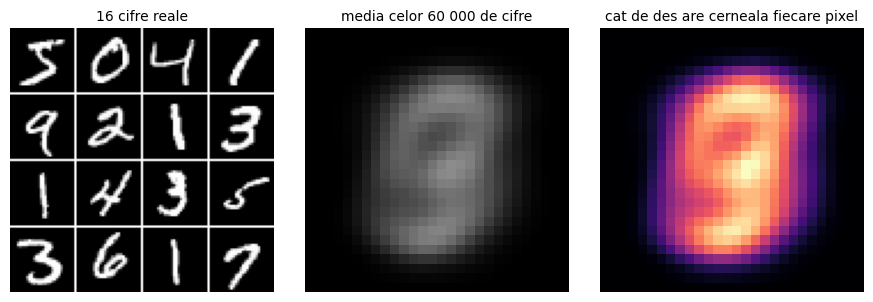

In [2]:
x_train, y_train = incarca_mnist()
loturi = [b.shape[0] for b in creeaza_dataset(x_train)]
print(f"forma {x_train.shape}, interval [{x_train.min():.0f}, {x_train.max():.0f}]")
print(f"pixeli exact -1 (fundal negru): {(x_train == -1).mean():.1%}   intermediari: {((x_train > -1) & (x_train < 1)).mean():.1%}")
print(f"{len(loturi)} loturi pe epoca, primul {loturi[0]}, ultimul {loturi[-1]}")

imagini = x_train.reshape(-1, 28, 28)
for w in (1, 2, 3, 4):
    m = np.ones((28, 28), bool); m[w:-w, w:-w] = False
    print(f"rama de {w}px complet neagra in {(imagini[:, m] == -1).all(1).mean():.1%} din imagini")

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
grila(x_train[:16], 4, 4, ax=ax[0], titlu="16 cifre reale")
ax[1].imshow(pentru_afisare(x_train.mean(0))[0], cmap="gray", vmin=0, vmax=1); ax[1].axis("off")
ax[1].set_title("media celor 60 000 de cifre", fontsize=10)
ax[2].imshow((x_train != -1).mean(0).reshape(28, 28), cmap="magma"); ax[2].axis("off")
ax[2].set_title("cat de des are cerneala fiecare pixel", fontsize=10)
plt.tight_layout(); plt.show()

**Ce contează pentru GAN:** 81% din pixeli sunt fundal negru pur, marginea e aproape mereu goală, iar cerneala stă într-un oval central. „Cifra medie” (mijloc) e prima formă pe care o învață generatorul (secțiunea 4) și servește drept **linie de bază leneșă** la evaluare: un generator util trebuie să producă mai mult decât această pată.

Ultimul lot are 96 de imagini, nu 128. În pasul de antrenare numărul de falsuri se ia din mărimea lotului real (`tf.shape(real)[0]`), nu e scris de mână ca 128, ca schimbarea lui `BATCH_SIZE` să nu dezechilibreze antrenarea în tăcere.

## 2. Arhitecturi

| | Generator G | Discriminator D |
|---|---|---|
| Intrare | z: 100 de numere din N(0, 1) | imagine de 784 de pixeli |
| Straturi | Dense(256) → Dense(512) → Dense(784) | Dense(512) → Dense(256) → Dense(1) |
| Activări ascunse | LeakyReLU(0.2) | LeakyReLU(0.2) |
| Ieșire | `tanh`: pixeli în [-1, 1] | `sigmoid`: P(imaginea e reală) |
| Parametri | 559 632 | 533 505 |

- **z nu codifică o cifră.** E doar o sămânță: același z dă mereu aceeași imagine (G e o funcție deterministă după antrenare), iar varietatea vine exclusiv din z-uri diferite.
- **LeakyReLU în loc de ReLU:** G învață numai din gradientul care trece prin D. ReLU taie complet gradientul pentru valorile negative; LeakyReLU lasă să treacă 20% din el.
- **Capacități apropiate:** G și D au aproape același număr de parametri. Un D mult mai puternic ar respinge orice fals cu încredere totală, iar G n-ar mai primi un semnal din care să învețe (ipoteză, netestată în acest laborator).

Mai jos: un G **netrenat** produce zgomot gri (valori aproape de 0, deci tanh(0) = 0 = gri), fără pixeli negri sau albi. Imaginile diferă între ele pentru că z-urile diferă, nu pentru că G ar ști ceva.

In [3]:
construieste_generator().summary()
construieste_discriminator().summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,632 (2.13 MB)

 Trainable params: 559,632 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

G netrenat: pixeli intre -0.77 si 0.76, 95% in (-0.5, 0.5)
acelasi z de doua ori -> diferenta maxima: 0.0


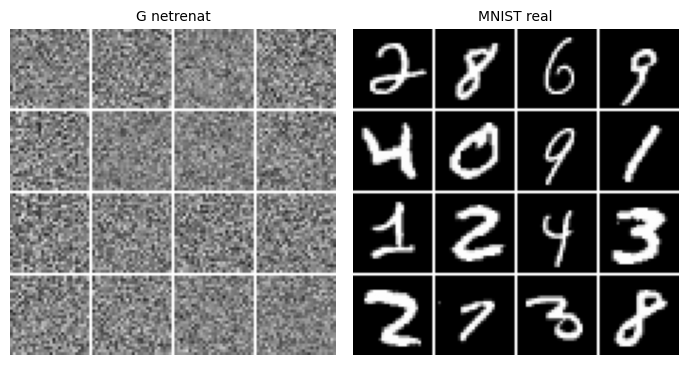

In [4]:
tf.random.set_seed(42)
G_netrenat = construieste_generator()
f0 = G_netrenat(tf.random.normal((16, LATENT_DIM)), training=False).numpy()
print(f"G netrenat: pixeli intre {f0.min():.2f} si {f0.max():.2f}, {(np.abs(f0) < 0.5).mean():.0%} in (-0.5, 0.5)")
z1 = tf.random.normal((1, LATENT_DIM))
print("acelasi z de doua ori -> diferenta maxima:", float(np.abs(G_netrenat(z1) - G_netrenat(z1)).max()))
fig, ax = plt.subplots(1, 2, figsize=(7, 3.6))
grila(f0, 4, 4, ax=ax[0], titlu="G netrenat")
grila(x_train[16:32], 4, 4, ax=ax[1], titlu="MNIST real")
plt.tight_layout(); plt.show()

## 3. Antrenare

Fiecare iterație (un lot de 128 de imagini reale) face două actualizări, în ordine:

1. **Discriminatorul învață.** G produce falsuri din z aleator. D e antrenat cu `d_loss = BCE(1, D(real)) + BCE(0, D(fals))`. Doar ponderile lui D se modifică.
2. **Generatorul învață.** Zgomot nou z, apoi `g_loss = BCE(1, D(G(z)))`: G vrea ca D să spună „real” despre falsurile lui. Gradientul trece **prin** D până la ponderile lui G, dar se aplică doar pe `G.trainable_variables`. Asta înseamnă concret „D înghețat”.

G **nu vede niciodată o imagine reală**. Informația despre cum arată MNIST ajunge la el doar indirect, prin gradientul discriminatorului.

![pasul de antrenare](diagrame/pas_antrenare.png)

Hiperparametri conform cerinței: BCE, câte un `Adam(2e-4, beta_1=0.5)` pentru fiecare rețea, loturi de 128, `latent_dim = 100`. Am antrenat **100 de epoci** (cerința minimă: 30), ca să vedem și ce se întâmplă după epoca 30. Pe CPU, o epocă durează ~8 s.

Ponderile au fost salvate la epocile **1, 2, 5, 7, 10, 15, 20, 30, 40, 50, 75, 100**: des la început, unde modelul se schimbă repede, și rar la final.

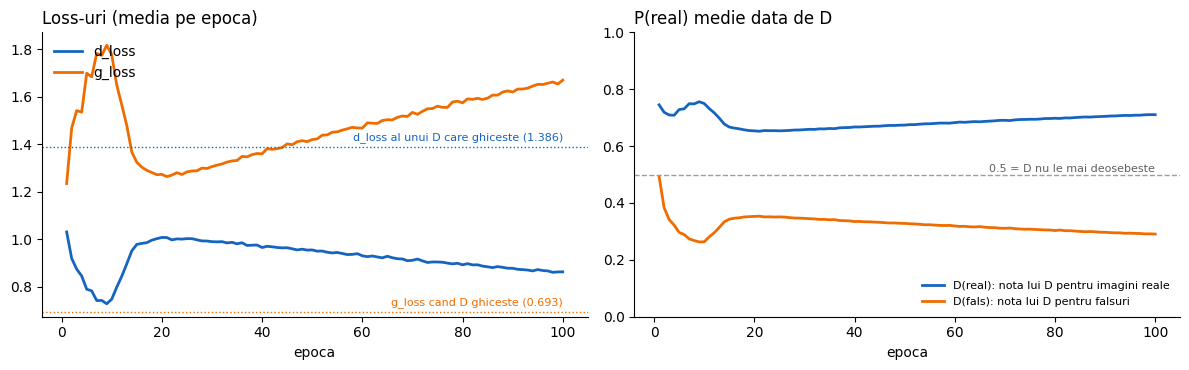

epoca   1: d_loss 1.031  g_loss 1.235  D(real) 0.745  D(fals) 0.494
epoca   5: d_loss 0.790  g_loss 1.699  D(real) 0.728  D(fals) 0.297
epoca  10: d_loss 0.748  g_loss 1.777  D(real) 0.750  D(fals) 0.263
epoca  15: d_loss 0.979  g_loss 1.324  D(real) 0.667  D(fals) 0.343
epoca  30: d_loss 0.990  g_loss 1.306  D(real) 0.658  D(fals) 0.346
epoca  50: d_loss 0.955  g_loss 1.420  D(real) 0.674  D(fals) 0.328
epoca 100: d_loss 0.863  g_loss 1.670  D(real) 0.710  D(fals) 0.291


In [5]:
ep = np.arange(1, len(istoric["d_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(ep, istoric["d_loss"], color=C_REAL, lw=2, label="d_loss")
ax[0].plot(ep, istoric["g_loss"], color=C_FALS, lw=2, label="g_loss")
ax[0].axhline(2 * np.log(2), color=C_REAL, ls=":", lw=1)
ax[0].axhline(np.log(2), color=C_FALS, ls=":", lw=1)
ax[0].text(100, 2 * np.log(2) + 0.03, "d_loss al unui D care ghiceste (1.386)", ha="right", fontsize=8, color=C_REAL)
ax[0].text(100, np.log(2) + 0.03, "g_loss cand D ghiceste (0.693)", ha="right", fontsize=8, color=C_FALS)
ax[0].set_title("Loss-uri (media pe epoca)", loc="left"); ax[0].set_xlabel("epoca"); ax[0].legend(frameon=False, loc="upper left")
ax[1].plot(ep, istoric["p_real"], color=C_REAL, lw=2, label="D(real): nota lui D pentru imagini reale")
ax[1].plot(ep, istoric["p_fake"], color=C_FALS, lw=2, label="D(fals): nota lui D pentru falsuri")
ax[1].axhline(0.5, color=C_BAZA, ls="--", lw=1); ax[1].text(100, 0.51, "0.5 = D nu le mai deosebeste", ha="right", fontsize=8, color="#616161")
ax[1].set_ylim(0, 1); ax[1].set_title("P(real) medie data de D", loc="left"); ax[1].set_xlabel("epoca")
ax[1].legend(frameon=False, loc="lower right", fontsize=8)
for a in ax: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
for e in (1, 5, 10, 15, 30, 50, 100):
    print(f"epoca {e:3d}: d_loss {istoric['d_loss'][e-1]:.3f}  g_loss {istoric['g_loss'][e-1]:.3f}  "
          f"D(real) {istoric['p_real'][e-1]:.3f}  D(fals) {istoric['p_fake'][e-1]:.3f}")

**Citirea graficelor.** Liniile punctate sunt referința unui D care ghicește (0.5 la tot): `d_loss = 2·ln 2 ≈ 1.386`, `g_loss = ln 2 ≈ 0.693`. D rămâne tot timpul sub această referință la loss (D(fals) ≈ 0.3, D(real) ≈ 0.7), deci deosebește încă realul de fals, dar nu câștigă niciodată clar. Asta e situația sănătoasă: D suficient de bun cât să dea feedback cu nuanțe, nu atât de bun încât să respingă orice.

Trei faze:
- **Epocile 1–10:** D câștigă teren (D(fals) scade la ~0.26, g_loss urcă la ~1.8).
- **Epocile 10–20:** G îl ajunge din urmă: D(fals) urcă la ~0.35, g_loss coboară la minimul său (~1.26, epoca ~21).
- **Epocile 20–100:** D recâștigă lent teren. d_loss scade de la ~1.0 la ~0.86, iar **g_loss crește continuu**, de la ~1.26 la ~1.67.

Citit ca într-o rețea obișnuită, g_loss în creștere ar însemna că G devine tot mai slab după epoca 20. Secțiunile 4 și 6 arată opusul: cifrele devin mai curate, iar judecătorul extern le dă o claritate tot mai mare.

## 4. Evoluția pe zgomot fix și generarea finală

Aceleași 16 z-uri, fixate înainte de antrenare, trecute prin G după fiecare epocă. Cum z nu se schimbă, orice diferență dintre grile vine numai din ponderile lui G. Grilele 4×4 sunt la fiecare 5 epoci, cum cere enunțul, pentru primele 30 de epoci; restul evoluției, până la 100, e pe rânduri (aceleași 16 poziții, în aceeași ordine).

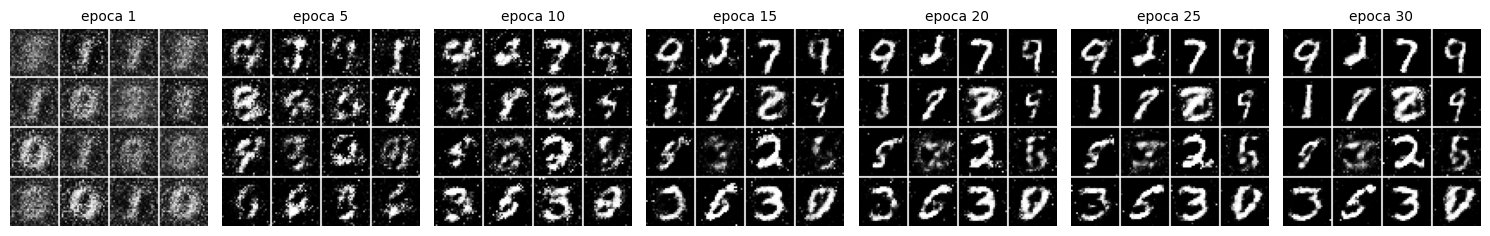

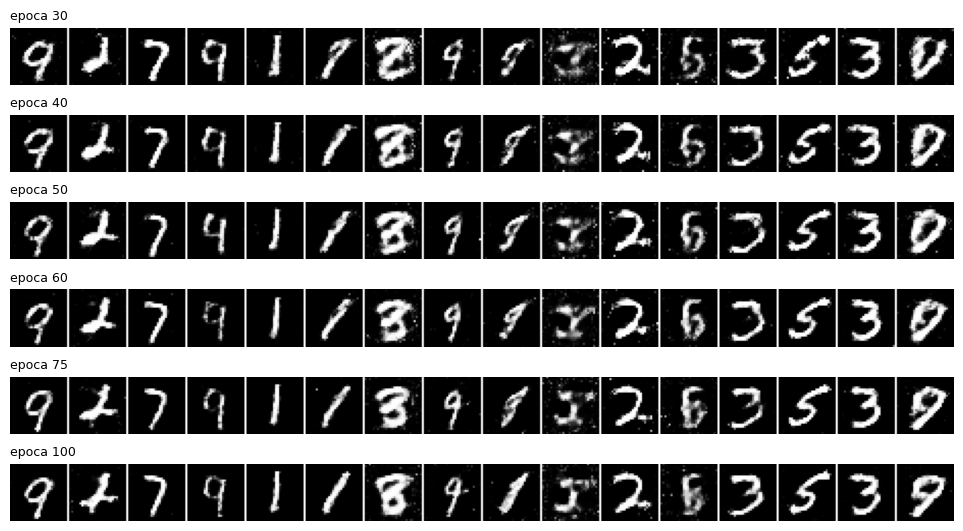

In [6]:
fig, ax = plt.subplots(1, 7, figsize=(15, 2.6))
for a, e in zip(ax, (1, 5, 10, 15, 20, 25, 30)):
    grila(evolutie[e - 1], 4, 4, ax=a, titlu=f"epoca {e}")
plt.tight_layout(); plt.show()

epoci_rand = (30, 40, 50, 60, 75, 100)
fig, ax = plt.subplots(len(epoci_rand), 1, figsize=(12, 0.9 * len(epoci_rand)))
for a, e in zip(ax, epoci_rand):
    grila(evolutie[e - 1], 1, 16, ax=a); a.set_title(f"epoca {e}", loc="left", fontsize=9)
plt.tight_layout(); plt.show()

- **Epoca 1:** o pată deschisă în centru, cu ramă întunecată. Seamănă cu „cifra medie” din secțiunea 1: cel mai ieftin lucru care îl încurcă pe D, fără niciun detaliu.
- **Epoca 5:** apar primele forme de cifră, înconjurate de puncte de zgomot.
- **Epocile 10–15:** majoritatea imaginilor au formă de cifră, dar cu trăsături rupte.
- **Epoca 20:** cifre recognoscibile pe aproape toate pozițiile.
- **Epocile 30–100:** aceleași cifre se curăță (zgomotul de pe fundal dispare, conturul devine continuu). Unele poziții își schimbă identitatea: poziția 9 trece de la „9” la „1”, iar poziția 16 de la „0” la „9” între epocile 60 și 75. Ambele schimbări merg în direcția dezechilibrului din secțiunea 6 (tot mai mulți de 1 și 9, tot mai puține zerouri). Poziția 10 rămâne o pată fără formă pe toată antrenarea: nu orice z ajunge la o cifră.

Generarea finală: 25 de cifre din **zgomot nou**, cu G de la epoca 100.

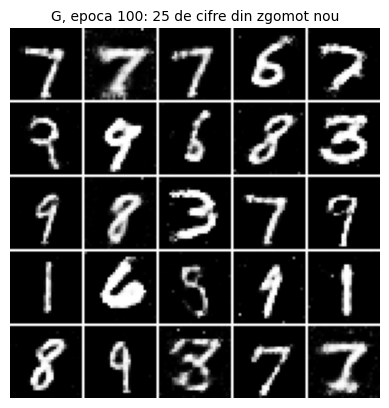

In [7]:
G = construieste_generator()
G.load_weights("checkpoints/G_ep100.weights.h5")
finale = G(tf.random.normal((25, LATENT_DIM), seed=2026), training=False).numpy()
grila(finale, 5, 5, marime=1.6, titlu="G, epoca 100: 25 de cifre din zgomot nou")
plt.show()

### De predat: observații

**Cifrele recognoscibile apar în jurul epocii 5 și devin clare pe aproape toate pozițiile la epoca 20; după epoca 30 se îmbunătățește în principal curățenia (fundal fără zgomot, contur continuu), nu forma.** Cifrele sunt variate ca stil (înclinare, grosime, mărime), dar **nu sunt echilibrate ca tip**: judecătorul extern (secțiunea 6) găsește la epoca 100 doar ~2% zerouri și câte ~17–18% de 1, 7 și 9, față de ~10% fiecare în MNIST. G are deci *mode dropping*: nu s-a blocat pe o singură cifră, dar produce mult mai rar unele cifre.

## 5. De ce loss-ul nu e o măsură a calității

Într-o rețea obișnuită loss-ul scade pe măsură ce modelul se îmbunătățește. Într-un GAN, D și G joacă unul împotriva celuilalt: când G se îmbunătățește, loss-ul lui D crește, deși totul merge bine. Loss-ul e scorul unui meci care rămâne strâns, nu o notă de progres.

Mai jos: cât de mult se schimbă imaginile din zgomotul fix de la o epocă la alta, pus lângă g_loss. g_loss atinge minimul în jurul epocii 21 și apoi crește, dar imaginile continuă să se schimbe, iar secțiunea 6 arată că schimbarea e o îmbunătățire. O regulă de early stopping pe loss-ul lui G (de exemplu „oprește dacă nu scade cu 0.005 în 5 epoci”) ar fi oprit antrenarea în jurul epocii 26.

Nici o valoare extremă a loss-ului nu marchează succesul: un G perfect duce D la 0.5 pe tot, exact aceeași valoare pe care o dă și un D slab. Extremele sunt doar alarme de eșec (D(fals) → 0 înseamnă că D a câștigat și G nu mai primește semnal).

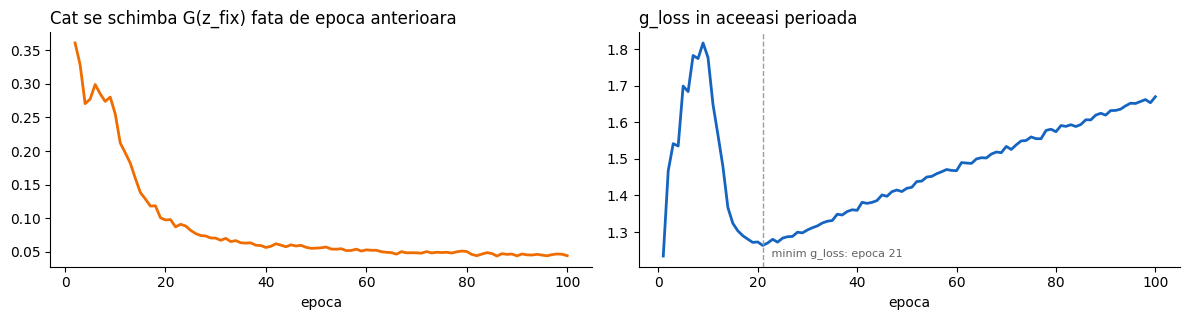

early stopping pe g_loss (rabdare 5, prag 0.005) ar fi oprit la epoca 26; claritatea judecatorului: ~0.83 la epoca 20 fata de 0.91 la epoca 100


In [8]:
schimbare = np.abs(np.diff(evolutie, axis=0)).mean(axis=(1, 2))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.3))
ax[0].plot(ep[1:], schimbare, color=C_FALS, lw=2)
ax[0].set_title("Cat se schimba G(z_fix) fata de epoca anterioara", loc="left"); ax[0].set_xlabel("epoca")
ax[1].plot(ep, istoric["g_loss"], color=C_REAL, lw=2)
e_min = int(np.argmin(istoric["g_loss"][5:])) + 6
ax[1].axvline(e_min, color=C_BAZA, ls="--", lw=1)
ax[1].text(e_min + 1, min(istoric["g_loss"]), f" minim g_loss: epoca {e_min}", fontsize=8, color="#616161")
ax[1].set_title("g_loss in aceeasi perioada", loc="left"); ax[1].set_xlabel("epoca")
for a in ax: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

# Regula de early stopping propusa: opreste daca g_loss nu scade cu 0.005 in 5 epoci.
# Primele 10 epoci sunt incalzire (altfel valoarea de la epoca 1 ramane record pentru totdeauna).
cel_mai_bun, rabdare, oprire = float("inf"), 0, None
for e, v in enumerate(istoric["g_loss"], 1):
    if e <= 10: continue
    if v < cel_mai_bun - 0.005: cel_mai_bun, rabdare = v, 0
    else: rabdare += 1
    if rabdare == 5: oprire = e; break
print(f"early stopping pe g_loss (rabdare 5, prag 0.005) ar fi oprit la epoca {oprire}; "
      f"claritatea judecatorului: ~{evaluare[20]['claritate']:.2f} la epoca 20 fata de {evaluare[100]['claritate']:.2f} la epoca 100")

## 6. Evaluare cu un judecător extern

Avem nevoie de un evaluator din afara jocului: un **clasificator MNIST** antrenat separat (două straturi convoluționale, 3 epoci, `src/judecator.py`), care nu participă la antrenarea GAN-ului. Pe 10 000 de cifre generate la fiecare checkpoint măsurăm două lucruri:

- **claritate**: încrederea medie a judecătorului (max softmax). Răspunde la „fiecare imagine arată clar ca o cifră?”
- **varietate**: cât de des apare fiecare cifră. Răspunde la „sunt diferite între ele?”. Un G bun ar da ~10% din fiecare.

E aceeași idee ca **Inception Score** din curs, la scară mică: un clasificator MNIST în loc de InceptionV3, iar cele două jumătăți sunt raportate întâi separat. La finalul secțiunii le contopim în Inception Score-ul propriu-zis.

Înainte de a măsura G, măsurăm judecătorul pe trei repere: cifre reale (podeaua), zgomot pur (capcana) și cifra medie (linia de bază leneșă).

In [9]:
J = incarca_judecator()
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_test = ((x_test.astype(np.float32) - 127.5) / 127.5).reshape(-1, 784)
print(f"acuratete judecator pe test: {(evalueaza(J, x_test)['cifre'] == y_test).mean():.4f}\n")

zgomot = np.random.default_rng(0).uniform(-1, 1, (10000, 784)).astype(np.float32)
repere = {
    "cifre reale (test)": evalueaza(J, x_test),
    "zgomot pur": evalueaza(J, zgomot),
    "cifra medie": evalueaza(J, np.repeat(x_train.mean(0, keepdims=True), 10, 0)),
}
for nume, r in repere.items():
    print(f"{nume:<20} claritate {r['claritate']:.3f} | cifra cea mai frecventa {r['distributie'].argmax()} "
          f"in {r['distributie'].max():.1%} | cea mai rara {r['distributie'].min():.1%}")

acuratete judecator pe test: 0.9846



cifre reale (test)   claritate 0.981 | cifra cea mai frecventa 1 in 11.3% | cea mai rara 9.0%
zgomot pur           claritate 0.910 | cifra cea mai frecventa 8 in 99.7% | cea mai rara 0.0%
cifra medie          claritate 0.309 | cifra cea mai frecventa 3 in 100.0% | cea mai rara 0.0%


**Zgomotul pur primește ~91% încredere** și e declarat „8” aproape de fiecare dată. Încrederea singură nu separă zgomotul de cifrele reale (0.91 față de 0.98); îl prinde doar varietatea, care e prăbușită pe o singură cifră. De aceea raportăm întotdeauna ambele măsuri.

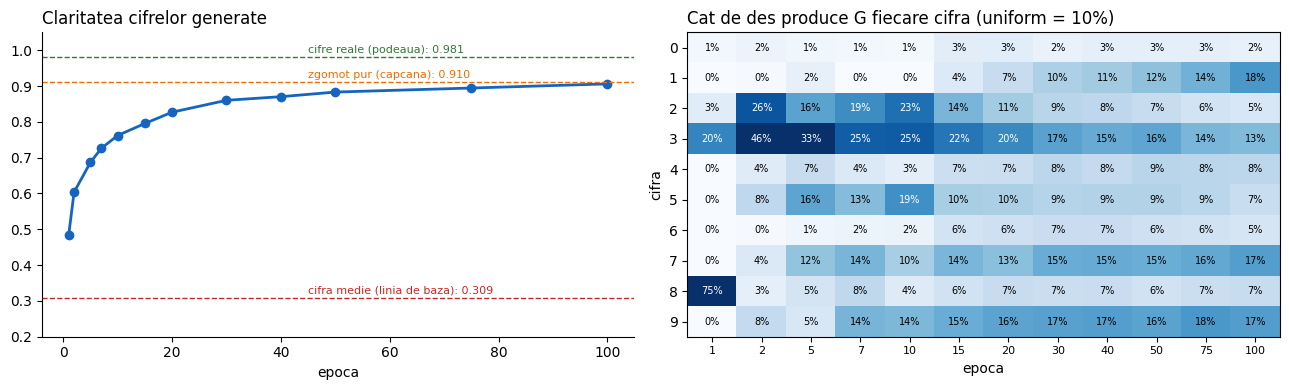

epoca   1 | claritate 0.483 | cea mai rara: 1 (0.0%) | cea mai frecventa: 8 (75.4%)
epoca   2 | claritate 0.604 | cea mai rara: 6 (0.3%) | cea mai frecventa: 3 (45.7%)
epoca   5 | claritate 0.687 | cea mai rara: 0 (1.1%) | cea mai frecventa: 3 (33.3%)
epoca   7 | claritate 0.726 | cea mai rara: 1 (0.1%) | cea mai frecventa: 3 (24.7%)
epoca  10 | claritate 0.762 | cea mai rara: 1 (0.1%) | cea mai frecventa: 3 (24.9%)
epoca  15 | claritate 0.795 | cea mai rara: 0 (3.1%) | cea mai frecventa: 3 (21.8%)
epoca  20 | claritate 0.827 | cea mai rara: 0 (3.2%) | cea mai frecventa: 3 (19.8%)
epoca  30 | claritate 0.860 | cea mai rara: 0 (2.1%) | cea mai frecventa: 9 (16.7%)
epoca  40 | claritate 0.870 | cea mai rara: 0 (2.8%) | cea mai frecventa: 9 (17.0%)
epoca  50 | claritate 0.883 | cea mai rara: 0 (2.8%) | cea mai frecventa: 9 (16.4%)
epoca  75 | claritate 0.894 | cea mai rara: 0 (2.7%) | cea mai frecventa: 9 (17.9%)
epoca 100 | claritate 0.906 | cea mai rara: 0 (2.3%) | cea mai frecventa: 1 

In [10]:
epoci_ev = sorted(evaluare)
claritate = [evaluare[e]["claritate"] for e in epoci_ev]
distributie = np.array([evaluare[e]["distributie"] for e in epoci_ev])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(epoci_ev, claritate, "o-", color=C_REAL, lw=2, ms=6)
for y, t, c in [(repere["cifre reale (test)"]["claritate"], "cifre reale (podeaua)", C_BUN),
                (repere["zgomot pur"]["claritate"], "zgomot pur (capcana)", C_FALS),
                (repere["cifra medie"]["claritate"], "cifra medie (linia de baza)", C_RAU)]:
    ax[0].axhline(y, color=c, ls="--", lw=1); ax[0].text(45, y + 0.012, f"{t}: {y:.3f}", fontsize=8, color=c)
ax[0].set_ylim(0.2, 1.05); ax[0].set_xlabel("epoca"); ax[0].set_title("Claritatea cifrelor generate", loc="left")
ax[0].spines[["top", "right"]].set_visible(False)

ax[1].imshow(distributie.T, aspect="auto", cmap="Blues", vmin=0, vmax=0.3)
ax[1].set_xticks(range(len(epoci_ev))); ax[1].set_xticklabels(epoci_ev, fontsize=8)
ax[1].set_yticks(range(10)); ax[1].set_xlabel("epoca"); ax[1].set_ylabel("cifra")
for i in range(len(epoci_ev)):
    for c in range(10):
        v = distributie[i, c]
        ax[1].text(i, c, f"{v:.0%}", ha="center", va="center", fontsize=7, color="white" if v > 0.18 else "black")
ax[1].set_title("Cat de des produce G fiecare cifra (uniform = 10%)", loc="left")
plt.tight_layout(); plt.show()

for e in epoci_ev:
    d = np.array(evaluare[e]["distributie"])
    print(f"epoca {e:3d} | claritate {evaluare[e]['claritate']:.3f} | cea mai rara: {d.argmin()} ({d.min():.1%}) "
          f"| cea mai frecventa: {d.argmax()} ({d.max():.1%})")

- **Claritatea crește continuu**, de la ~0.48 la epoca 1 la ~0.91 la epoca 100, inclusiv în epocile 20–100, în care g_loss crește. Judecătorul vede progresul pe care loss-ul îl arată invers, deci o regulă de oprire trebuie pusă pe o astfel de măsură, nu pe loss.
- **Epoca 1 e capcana:** claritatea trece de cifra medie, dar ~75% din imagini sunt declarate „8”, la fel ca zgomotul pur. Trece la claritate, pică la varietate.
- **Varietatea se îmbunătățește, dar nu ajunge uniformă.** De la epoca 15 toate cifrele apar, însă 0 rămâne la 2–3% pe toată antrenarea, iar 1 crește de la 0% la ~18%. Motivul de fond: nimic din loss nu răsplătește varietatea. D întreabă doar „pare real?”, niciodată „ai desenat toate cifrele?”, deci un G care face mai ales 1, 7 și 9 îl păcălește la fel de bine.
- Claritatea finală rămâne sub podeaua cifrelor reale (0.98).

**Control vizual** (metricile pot minți): imaginile de la epoca 100 grupate după cifra pe care o vede judecătorul, plus cele mai nesigure 16.

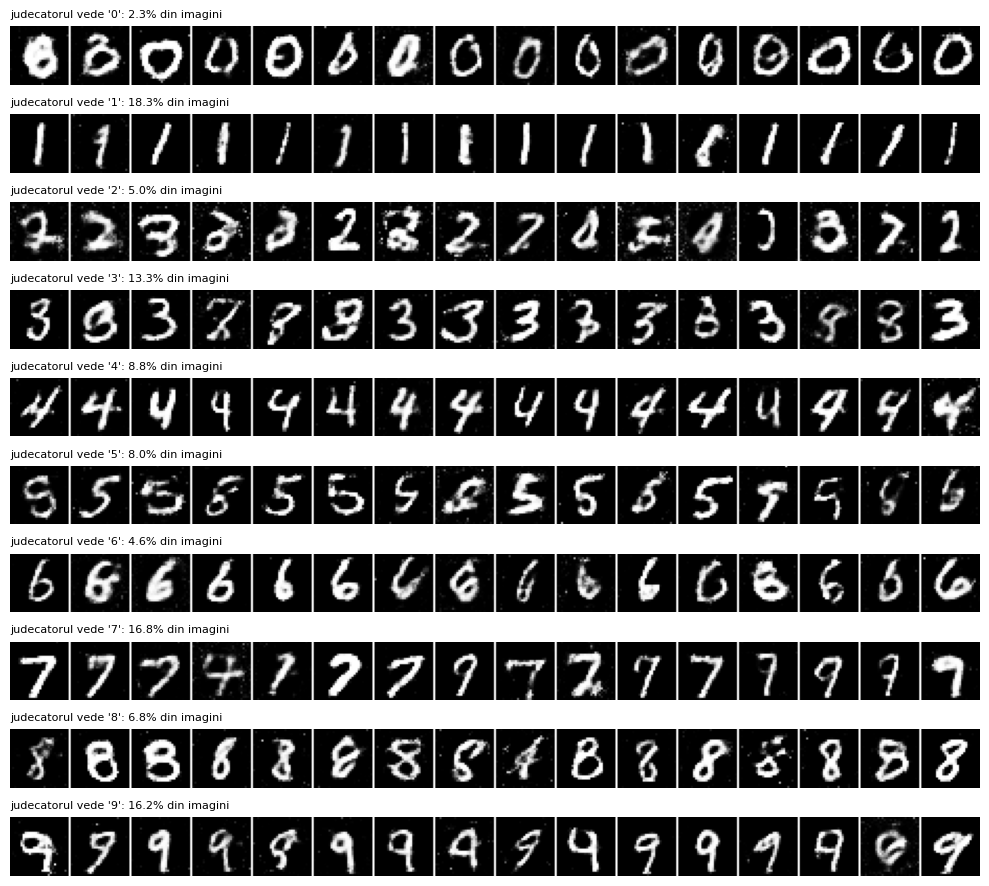

imagini cu incredere sub 0.5: 4.0%


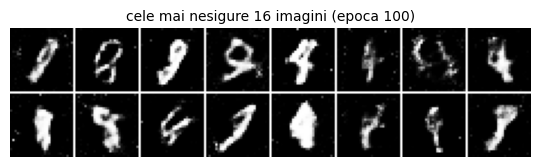

In [11]:
z_ev = tf.random.normal((10000, LATENT_DIM), seed=123)
gen = G(z_ev, training=False).numpy()
r = evalueaza(J, gen)
fig, ax = plt.subplots(10, 1, figsize=(10, 9))
for c in range(10):
    grila(gen[r["cifre"] == c][:16], 1, 16, ax=ax[c])
    ax[c].set_title(f"judecatorul vede '{c}': {r['distributie'][c]:.1%} din imagini", loc="left", fontsize=8)
plt.tight_layout(); plt.show()

nesigure = np.argsort(r["incredere"])[:16]
print(f"imagini cu incredere sub 0.5: {(r['incredere'] < 0.5).mean():.1%}")
grila(gen[nesigure], 2, 8, marime=1.4, titlu="cele mai nesigure 16 imagini (epoca 100)")
plt.show()

- Cele ~2% de „0” **chiar sunt zerouri**: lipsa lor e reală, nu o eroare a judecătorului.
- Rândurile „1”, „7”, „4” sunt aproape toate cifre curate.
- Rândul „2” conține multe imagini ambigue (jumătăți de 7, 3 sau 8). Judecătorul e obligat să aleagă o clasă, deci distribuția e o măsurătoare bună, dar nu perfectă: procentul de „2” include și rebuturi.
- Imaginile cele mai nesigure sunt forme la granița dintre două cifre, nu zgomot.

### Inception Score: cele două măsuri într-un singur număr

Cursul definește **IS = exp(E_x[KL(p(y|x) ‖ p(y))])**. Folosim aceleași probabilități ale judecătorului, deci IS conține aceeași informație ca măsurile de mai sus, contopită. Pe MNIST scala e clară: **1** înseamnă o singură cifră sau nesiguranță totală, **10** înseamnă toate cele 10 cifre în proporții egale, fiecare recunoscută cu siguranță deplină.

Formula se desface exact în cele două jumătăți din această secțiune:

**IS = cifre efective / ezitare**

- **cifre efective** = exp(H(p(y))): câte cifre produce G efectiv; 10 = distribuție uniformă (varietatea)
- **ezitare** = exp(E_x[H(p(y|x))]): între câte cifre ezită judecătorul, în medie, pe o imagine; 1 = sigur (claritatea)

Două diferențe față de exemplul 3_3 din curs (`src/judecator.py`):
- p(y) se calculează în fiecare dintre cele 10 părți separat, nu o singură dată pe tot setul. Deviația standard reflectă astfel și variația lui p(y) între părți.
- Exemplul 3_3 încarcă InceptionV3 cu `include_top=False` și aplică softmax pe cele 2048 de trăsături, care nu sunt probabilități de clasă. Judecătorul nostru dă direct p(y|x) pe cele 10 cifre.

                                 IS  cifre efective   ezitare  claritate
cifre reale (test)       9.35 ± 0.21            9.98      1.07      0.981
zgomot pur               1.04 ± 0.00            1.42      1.36      0.910
cifra medie              1.00 ± 0.00            6.69      6.69      0.309
G, epoca 100             6.58 ± 0.10            8.56      1.30      0.906


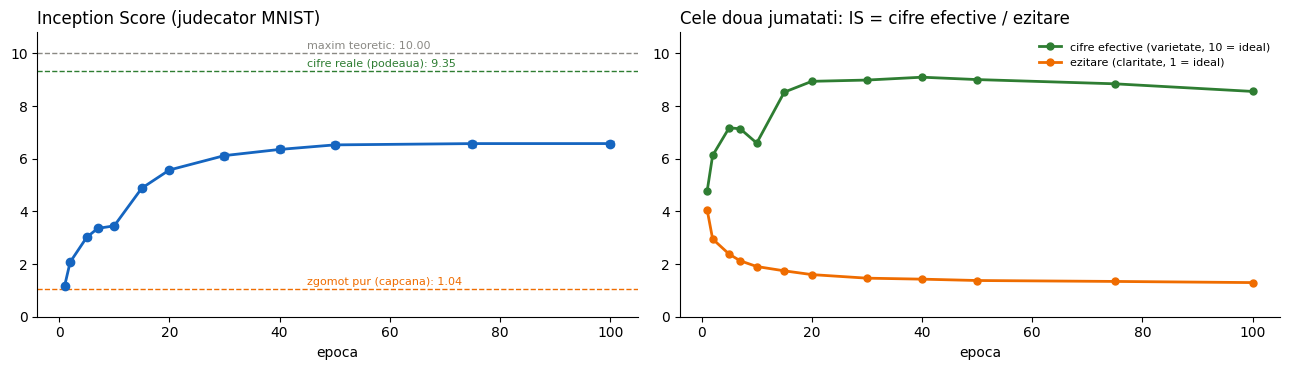

epoca   1 | IS 1.17 = 4.77 cifre efective / 4.07 ezitare
epoca   2 | IS 2.07 = 6.12 cifre efective / 2.95 ezitare
epoca   5 | IS 3.01 = 7.18 cifre efective / 2.38 ezitare
epoca   7 | IS 3.35 = 7.14 cifre efective / 2.12 ezitare
epoca  10 | IS 3.45 = 6.59 cifre efective / 1.91 ezitare
epoca  15 | IS 4.88 = 8.53 cifre efective / 1.74 ezitare
epoca  20 | IS 5.57 = 8.94 cifre efective / 1.60 ezitare
epoca  30 | IS 6.12 = 8.99 cifre efective / 1.46 ezitare
epoca  40 | IS 6.35 = 9.10 cifre efective / 1.43 ezitare
epoca  50 | IS 6.53 = 9.01 cifre efective / 1.38 ezitare
epoca  75 | IS 6.57 = 8.85 cifre efective / 1.34 ezitare
epoca 100 | IS 6.58 = 8.56 cifre efective / 1.30 ezitare


In [12]:
print(f"{'':<22}{'IS':>13}{'cifre efective':>16}{'ezitare':>10}{'claritate':>11}")
# randul lui G vine din istoric, acelasi esantion ca graficul de mai jos
for nume, rr in [*repere.items(), ("G, epoca 100", evaluare[100])]:
    print(f"{nume:<22}{rr['is']:>7.2f} ± {rr['is_std']:.2f}{rr['cifre_efective']:>16.2f}"
          f"{rr['ezitare']:>10.2f}{rr['claritate']:>11.3f}")

is_ep = np.array([evaluare[e]["is"] for e in epoci_ev])
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].errorbar(epoci_ev, is_ep, yerr=[evaluare[e]["is_std"] for e in epoci_ev],
               fmt="o-", color=C_REAL, lw=2, ms=6, capsize=3)
for y, t, c in [(10, "maxim teoretic", "#8a8984"),
                (repere["cifre reale (test)"]["is"], "cifre reale (podeaua)", C_BUN),
                (repere["zgomot pur"]["is"], "zgomot pur (capcana)", C_FALS)]:
    ax[0].axhline(y, color=c, ls="--", lw=1); ax[0].text(45, y + 0.15, f"{t}: {y:.2f}", fontsize=8, color=c)
ax[0].set_ylim(0, 10.8); ax[0].set_xlabel("epoca"); ax[0].set_title("Inception Score (judecator MNIST)", loc="left")

ax[1].plot(epoci_ev, [evaluare[e]["cifre_efective"] for e in epoci_ev], "o-", color=C_BUN, lw=2, ms=5,
           label="cifre efective (varietate, 10 = ideal)")
ax[1].plot(epoci_ev, [evaluare[e]["ezitare"] for e in epoci_ev], "o-", color=C_FALS, lw=2, ms=5,
           label="ezitare (claritate, 1 = ideal)")
ax[1].set_ylim(0, 10.8); ax[1].set_xlabel("epoca"); ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title("Cele doua jumatati: IS = cifre efective / ezitare", loc="left")
for a in ax: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

for e in epoci_ev:
    v = evaluare[e]
    print(f"epoca {e:3d} | IS {v['is']:.2f} = {v['cifre_efective']:.2f} cifre efective / {v['ezitare']:.2f} ezitare")

- **Zgomotul pur, care păcălea claritatea (0.91), primește IS 1.04, aproape minimul.** Judecătorul pune aproape toate imaginile de zgomot în aceeași clasă („8”), deci varietatea e aproape zero și IS o prinde singur.
- **Cifra medie primește exact 1.00:** toate imaginile sunt identice, deci p(y|x) = p(y) și KL = 0.
- **Cifrele reale dau 9.35, nu 10.** Aceasta e podeaua practică a acestui judecător, iar comparația corectă pentru G e cu 9.35.
- **G la epoca 100 ajunge la 6.58** și pierde pe ambele jumătăți: are 8.56 cifre efective față de 9.98 la cifrele reale (mode dropping) și ezitare 1.30 față de 1.07 (imagini ambigue).
- **IS stagnează după epoca 50** (6.53 → 6.58), deși claritatea crește în continuare. Descompunerea arată de ce: ezitarea scade (1.38 → 1.30), dar numărul de cifre efective scade și el, de la 9.10 (epoca 40) la 8.56, pe măsură ce G produce tot mai mulți de 1. Cele două se anulează. Un singur număr ar fi ascuns asta; de aceea le raportăm și separat.
- La epoca 1, cifrele efective sunt 4.77, deși judecătorul numește „8” 75% din imagini: p(y) se calculează din probabilitățile întregi, iar imaginile nesigure își împart masa între mai multe cifre.

## 7. Control: a memorat G setul de antrenare?

O obiecție plauzibilă: G ar putea produce cifre clare pur și simplu copiind imagini din setul de antrenare. Test: pentru fiecare cifră generată căutăm cea mai apropiată imagine din cele 60 000 de antrenare (distanță L2 pe pixeli). Referința corectă nu este 0, ci ce distanță au **cifrele reale de test**, pe care G nu le-a văzut niciodată, față de setul de antrenare. Dacă G ar copia, cifrele lui ar fi mult mai aproape de antrenare decât cele de test.

generat -> antrenare: mediana 8.61, minim 2.65, sub 4.0: 6.2%
test    -> antrenare: mediana 8.77, minim 2.25, sub 4.0: 10.6%


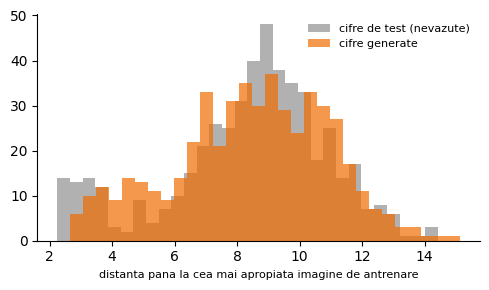

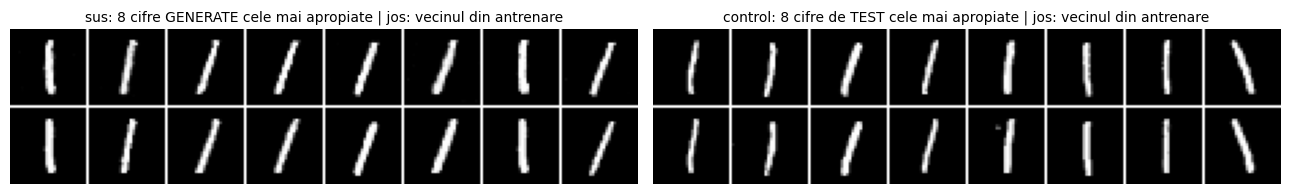

In [13]:
gen_nn = G(tf.random.normal((500, LATENT_DIM), seed=2026), training=False).numpy()
d_gen, i_gen = distante_la_cel_mai_apropiat(gen_nn, x_train)
d_test, i_test = distante_la_cel_mai_apropiat(x_test[:500], x_train)
print(f"generat -> antrenare: mediana {np.median(d_gen):.2f}, minim {d_gen.min():.2f}, sub 4.0: {(d_gen < 4).mean():.1%}")
print(f"test    -> antrenare: mediana {np.median(d_test):.2f}, minim {d_test.min():.2f}, sub 4.0: {(d_test < 4).mean():.1%}")

fig, ax0 = plt.subplots(figsize=(5, 3))
ax0.hist(d_test, bins=30, color=C_BAZA, alpha=0.8, label="cifre de test (nevazute)")
ax0.hist(d_gen, bins=30, color=C_FALS, alpha=0.7, label="cifre generate")
ax0.set_xlabel("distanta pana la cea mai apropiata imagine de antrenare", fontsize=8); ax0.legend(frameon=False, fontsize=8)
ax0.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 2.4))
a = np.argsort(d_gen)[:8]
grila(np.concatenate([gen_nn[a], x_train[i_gen[a]]]), 2, 8, ax=ax[0],
      titlu="sus: 8 cifre GENERATE cele mai apropiate | jos: vecinul din antrenare")
a = np.argsort(d_test)[:8]
grila(np.concatenate([x_test[:500][a], x_train[i_test[a]]]), 2, 8, ax=ax[1],
      titlu="control: 8 cifre de TEST cele mai apropiate | jos: vecinul din antrenare")
plt.tight_layout(); plt.show()

Cele două histograme se suprapun: cifrele generate sunt cam la fel de departe de setul de antrenare ca niște cifre reale pe care G nu le-a văzut (mediane apropiate, vezi valorile de mai sus).

**Cazurile cele mai apropiate cer atenție.** Cele 8 cifre generate cele mai apropiate de antrenare sunt toate „1” și arată aproape identic cu vecinul lor. Luate singure, ar sugera copiere. Controlul din dreapta arată însă același lucru pentru cifrele **de test**: și cele mai apropiate cifre reale nevăzute sunt tot „1”-uri aproape identice cu un „1” din antrenare. Un „1” are puține forme posibile (o linie, mai dreaptă sau mai înclinată), iar printre 60 000 de imagini există aproape sigur unul foarte asemănător. Apropierea vine din simplitatea cifrei, nu din memorare.

**Concluzie: G nu copiază setul de antrenare; produce cifre la fel de „noi” ca niște cifre reale nevăzute.**

## 8. Concluzii


Am învățat în această lucrare cum funcționează GAN-urile și am observat și diferențe de arhitectură față de VAE din lab. 2 Am observat că valoarea loss nu este de încredere într-un sistem GAN deoarece Generatorul mereu înecarcă să păcălească Discriminatorul, care are scopul să nu fie păcălit de Generator, deci unul se îmbunătățește pe celălalt (lucru foarte de interesant, in my opinion).
Din cauza ca metrica loss e folositoare in cazul GAN-urilor, asta se introduce o metrica noua pentru mine, pe nume `Inception Score`, care măsoară Claritatea unei imagini, și Diversificarea acesteia, astfel putem vedea daca Generatorul e leneș și generează aceleași imagini fake, sau chiar sunt aleatorii.
